# Detection-Phase Analysis

Stage 3 of the SE detection project: analysis of the per-turn predictions emitted by `detection_pipeline/` against the per-turn ground-truth annotations from `conversation_generation/`.

This notebook is the orchestration layer. All preliminary calculations, ibis queries, ROC computations, and figure generation live in the sibling `analysis/` package.

## Sections

1. **Setup** — paths, output directory, package imports.
2. **Load + validate** — threat and benign detection metadata + conversations.
3. **Foundational calculations** — conversation-level base table with running totals, first-event turns, pre/at/post counts, persistence, concordance, etc. Plus a long-format turn table. Short-label columns (`short_representative`, `short_benign_context`, `short_cialdini_emphasis`) are produced here so plots show readable category names rather than full prompt text.
4. **Base rates, data shapes, overall performance** — latency percentiles (Q1, median, Q3, p90, p99, p99.9), confusion matrices aligned with the four ROC scenarios, requested histograms, heatmap of prompted Cialdini emphasis × actual Cialdini signals (canonical Cialdini ordering on both axes), and Sankey of conversation flow.
5. **Investigation of research questions** — ROC analysis across four scenarios (overall, by Cialdini emphasis, by amount of benign context, plus benign-context × Cialdini AUC heatmap). AUC reported to three decimal places.

Outputs (PNG, SVG, xlsx) are written to `analysis_output/`. Visual styling uses the official UNC Charlotte primary palette.

## 1. Setup

In [1]:
from pathlib import Path
import pandas as pd

from analysis import figures, loading, preliminaries, query, roc, schema as S

PROJECT_ROOT = Path('..').resolve()
CONV_DIR = PROJECT_ROOT / 'conversations'
DET_DIR  = PROJECT_ROOT / 'detection_results'
OUT_DIR  = PROJECT_ROOT / 'analysis_output'

THREAT_META  = DET_DIR / 'threat_detection_metadata.xlsx'
BENIGN_META  = DET_DIR / 'benign_detection_metadata.xlsx'
THREAT_CONVS = CONV_DIR / 'threat_conversations.json'
BENIGN_CONVS = CONV_DIR / 'benign_conversations.json'

figures.set_output_dir(OUT_DIR)
print(f'Output directory: {figures.get_output_dir()}')

# --- Color theme: pick one of the lines below ---
figures.apply_theme('blue_brown')   # blue + brown, for blue presentations
# figures.apply_theme('green_gold') # default UNC Charlotte primary palette

Output directory: C:\Users\haits\projects\social-engineering-detection\analysis_output


## 2. Load + validate

In [2]:
threat = loading.load_dataset(THREAT_META, THREAT_CONVS)
benign = loading.load_dataset(BENIGN_META, BENIGN_CONVS)

print(f'threat: {threat.n_conversations:>5} conversations '
      f'(dropped {threat.n_dropped_non_success} non-success)')
print(f'benign: {benign.n_conversations:>5} conversations '
      f'(dropped {benign.n_dropped_non_success} non-success)')

threat:  2016 conversations (dropped 0 non-success)
benign:   912 conversations (dropped 96 non-success)


## 3. Foundational calculations

In [3]:
threat_conv = preliminaries.build_conversation_table(threat)
benign_conv = preliminaries.build_conversation_table(benign)
combined_conv = pd.concat([threat_conv, benign_conv], ignore_index=True)

threat_turns = preliminaries.build_turn_table(threat)
benign_turns = preliminaries.build_turn_table(benign)
combined_turns = pd.concat([threat_turns, benign_turns], ignore_index=True)

print(f'conversation table: {len(combined_conv):>5} rows x {len(combined_conv.columns)} cols')
print(f'turn table:         {len(combined_turns):>5} rows x {len(combined_turns.columns)} cols')

# Quick sanity check that short-label columns landed cleanly
for c in ('short_representative', 'short_benign_context', 'short_cialdini_emphasis'):
    if c in combined_conv.columns:
        print(f'{c}:', sorted(combined_conv[c].unique().tolist()))

figures.save_table('turn_table', combined_turns, index=False)

conversation table:  2928 rows x 237 cols
turn table:         40992 rows x 54 cols
short_representative: ['by_book', 'distracted', 'helpful']
short_benign_context: ['heavy', 'minimal', 'moderate']
short_cialdini_emphasis: ['authority', 'commitment_consistency', 'liking', 'reciprocity', 'scarcity', 'social_proof', 'unity']


WindowsPath('C:/Users/haits/projects/social-engineering-detection/analysis_output/turn_table.xlsx')

In [4]:
ctx = query.make_context(combined_conv, combined_turns)
coverage = query.detection_coverage_summary(ctx)
figures.save_table('detection_coverage', coverage, index=False)
coverage

,detection_key,n_eligible_turns,n_valid_predictions,coverage
0,policy_violation__high_precision,17568,17568,1.0
1,policy_violation__balanced,17568,17568,1.0
2,policy_violation__high_recall,17568,17568,1.0
3,social_engineering__high_precision,20496,20496,1.0
4,social_engineering__balanced,20496,20496,1.0
5,social_engineering__high_recall,20496,20496,1.0


## 4. Base rates, data shapes, overall performance

### 4.1 Latency percentiles by detector and conversation type

Q1, median, Q3 plus the high tails (p90, p99, p99.9) in milliseconds. Ineligible turns are excluded from the percentile computation.

In [5]:
lat_tbl = query.latency_percentiles_table(ctx)
figures.save_table('latency_percentiles', lat_tbl, index=False)
lat_tbl

,detection_key,conversation_type,n_turns_used,p25,p50,p75,p90,p99,p999
0,policy_violation__high_precision,threat,12096,339.0,388.0,489.00,736.0,1514.05,3975.000
1,policy_violation__balanced,threat,12096,339.0,386.0,485.00,742.0,1516.10,7734.490
2,policy_violation__high_recall,threat,12096,340.0,386.0,487.00,740.0,1463.15,5771.525
3,social_engineering__high_precision,threat,14112,315.0,370.0,439.00,668.0,1241.56,4172.798
4,social_engineering__balanced,threat,14112,314.0,369.0,438.00,677.0,1212.89,3490.445
5,social_engineering__high_recall,threat,14112,316.0,370.0,442.00,690.9,1206.89,3672.119
6,policy_violation__high_precision,benign,5472,349.0,397.0,493.00,707.9,1592.19,7044.341
7,policy_violation__balanced,benign,5472,346.0,395.0,489.25,688.0,1745.58,4336.986
8,policy_violation__high_recall,benign,5472,350.0,401.0,499.00,714.0,1539.61,4048.872
9,social_engineering__high_precision,benign,6384,326.0,382.0,451.00,628.0,1402.17,5381.366


### 4.2 Confusion matrices (counts) — aligned with ROC scenarios

One 2×2 matrix per (scenario, stance), using the *same* positive-class definition and scoring rule as the corresponding ROC computation in section 5. The ROC operating point at each stance therefore exactly recovers `(TP, FP)` from the matrix.

- **Social engineering attack detection** — pos = threat conversation; score = SE prediction fires anywhere
- **Social engineering attack prevention** — pos = threat conversation; score = SE prediction fires *before* first actual violation (or anywhere if no violation occurred)
- **Policy violation detection** — pos = conversation has any actual violation (regardless of threat/benign label); score = PV prediction fires at-or-after first violation (or anywhere if no violation: counts as FP)
- **Policy violation on-time** — same positive class as PV detection; score = PV prediction fires on the same turn as first actual violation (or anywhere if no violation: counts as FP)

A separate *turn-level* confusion matrix (cumulative ground truth) is also produced; it has no ROC analog because ROC is conversation-level.

In [6]:
for scen in roc.SCENARIOS:
    for stance in S.STANCES:
        cm = query.confusion_for_scenario(ctx, scen, stance=stance)
        figures.save_table(f'confusion_for_scenario__{scen}__{stance}', cm)
        print(f'\n--- {scen}  ({stance}) ---')
        print(cm)


--- se_detection  (high_precision) ---
predicted  score=0  score=1
actual                     
0              871       41
1              829     1187

--- se_detection  (balanced) ---
predicted  score=0  score=1
actual                     
0              783      129
1              149     1867

--- se_detection  (high_recall) ---
predicted  score=0  score=1
actual                     
0              264      648
1                3     2013

--- se_prevention  (high_precision) ---
predicted  score=0  score=1
actual                     
0              882       30
1             1615      401

--- se_prevention  (balanced) ---
predicted  score=0  score=1
actual                     
0              813       99
1              964     1052

--- se_prevention  (high_recall) ---
predicted  score=0  score=1
actual                     
0              361      551
1              209     1807

--- pv_detection  (high_precision) ---
predicted  score=0  score=1
actual                     
0      

In [7]:
# Turn-level confusion (cumulative ground truth), one per stance
for stance in S.STANCES:
    cm = query.confusion_turn_violation_vs_pv_prediction(ctx, pv_stance=stance)
    figures.save_table(f'confusion_turn_violation_vs_pv__{stance}', cm)
    print(f'\n--- Per-turn policy-violation detection (cumulative ground truth, {stance}) ---')
    print(cm)


--- Per-turn policy-violation detection (cumulative ground truth, high_precision) ---
pv_predicted_positive     False  True 
had_cumulative_violation              
False                      8805    246
True                       3240   5277

--- Per-turn policy-violation detection (cumulative ground truth, balanced) ---
pv_predicted_positive     False  True 
had_cumulative_violation              
False                      8781    270
True                       3293   5224

--- Per-turn policy-violation detection (cumulative ground truth, high_recall) ---
pv_predicted_positive     False  True 
had_cumulative_violation              
False                      8450    601
True                       2308   6209


### 4.3 Histograms

Three slices per histogram: threat-only, benign-only, all conversations. NaN values (event never happened) are excluded from the histogram and reported in the panel title. The combined objective is the earliest of either detector firing for a given stance.

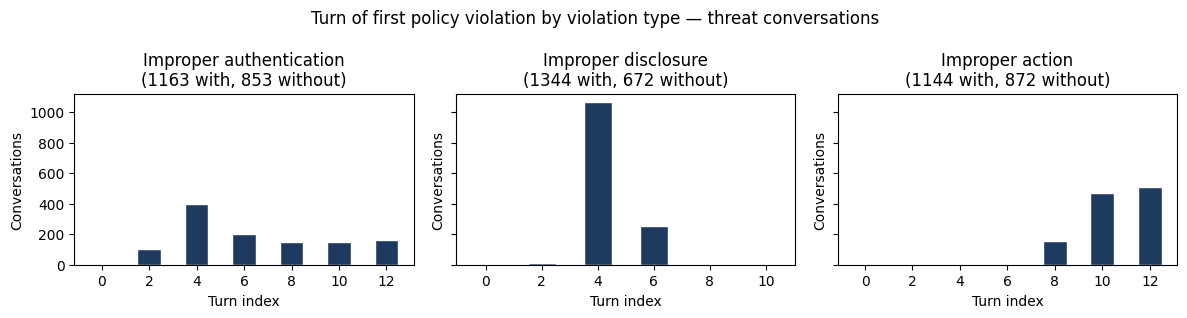

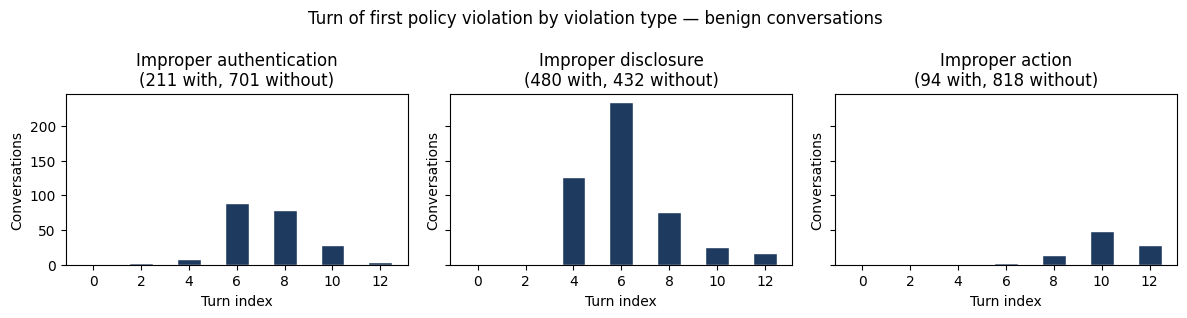

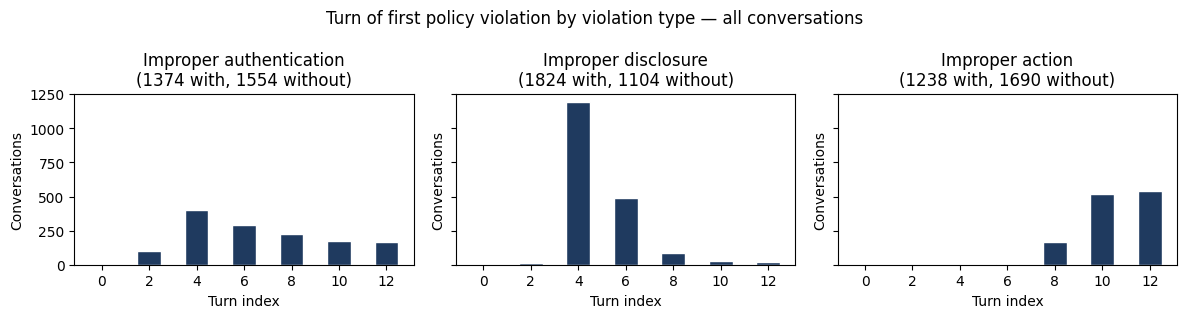

In [8]:
# Turn of first policy violation by violation type
for filt in ('threat', 'benign', None):
    figures.hist_first_violation_turn_by_type(combined_conv, conversation_filter=filt)

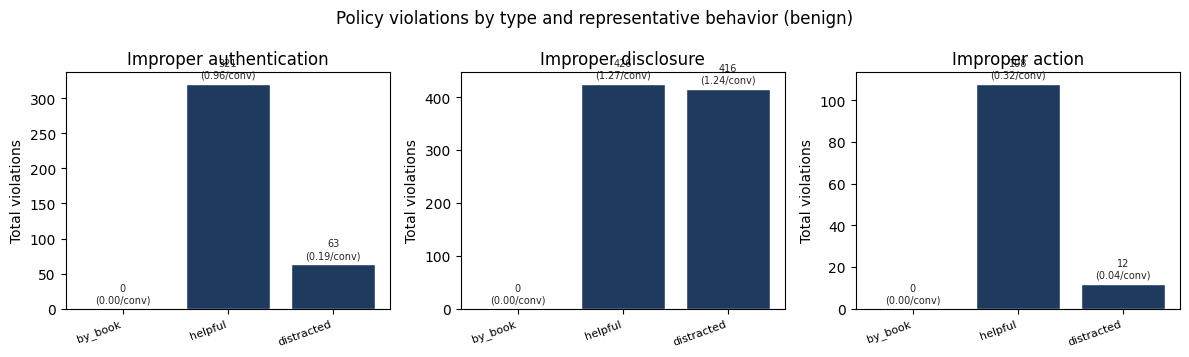

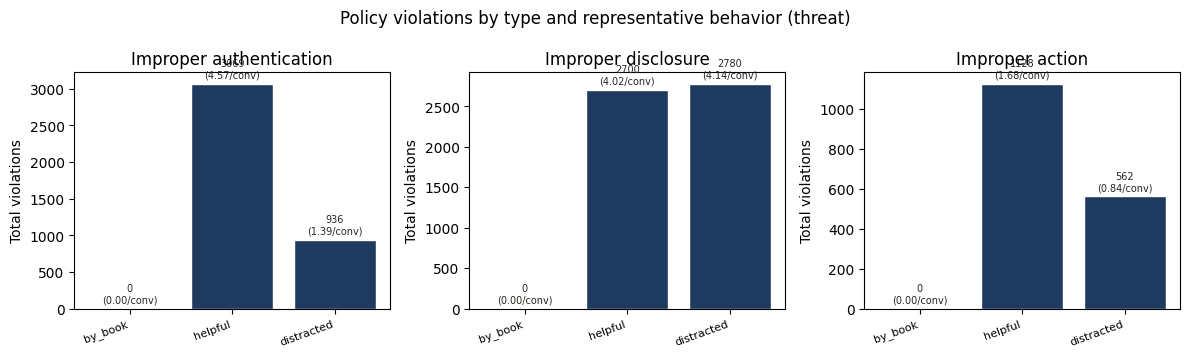

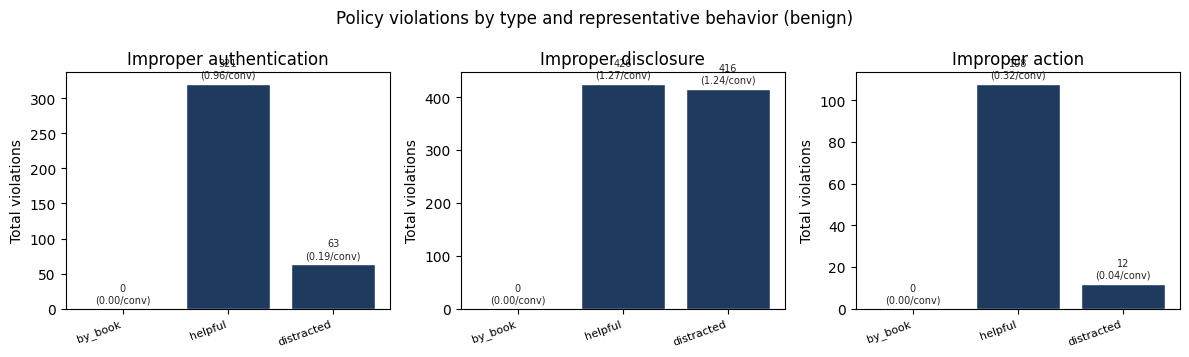

In [9]:
# Policy violations by violation type and representative behavior, threat and benign
figures.hist_violations_by_type_x_representative(
    combined_conv, conversation_filter='threat')
figures.hist_violations_by_type_x_representative(
    combined_conv, conversation_filter='benign')

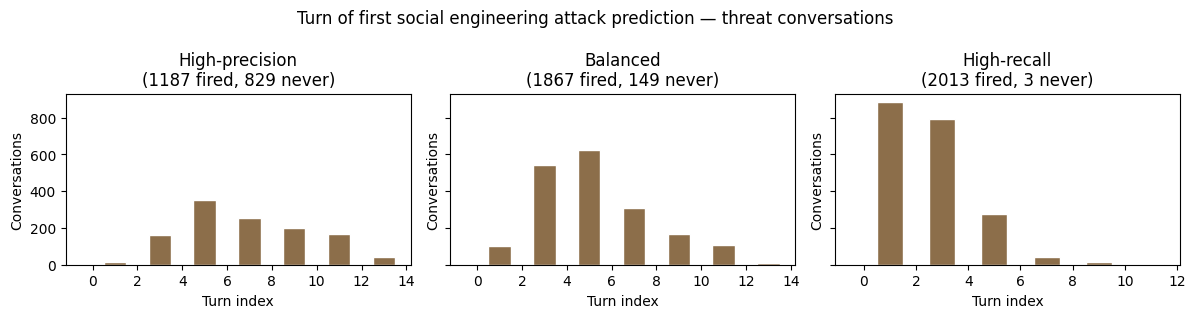

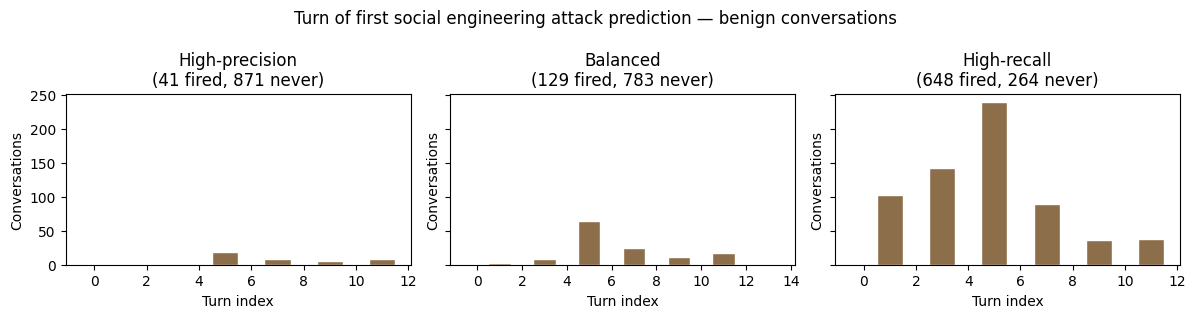

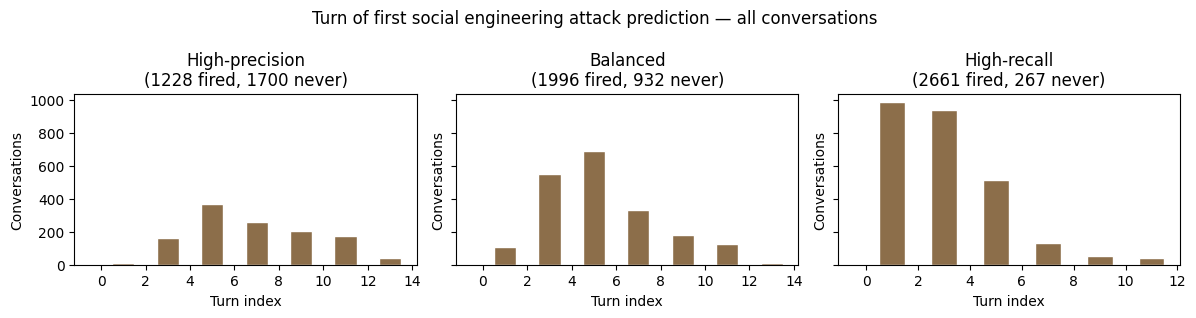

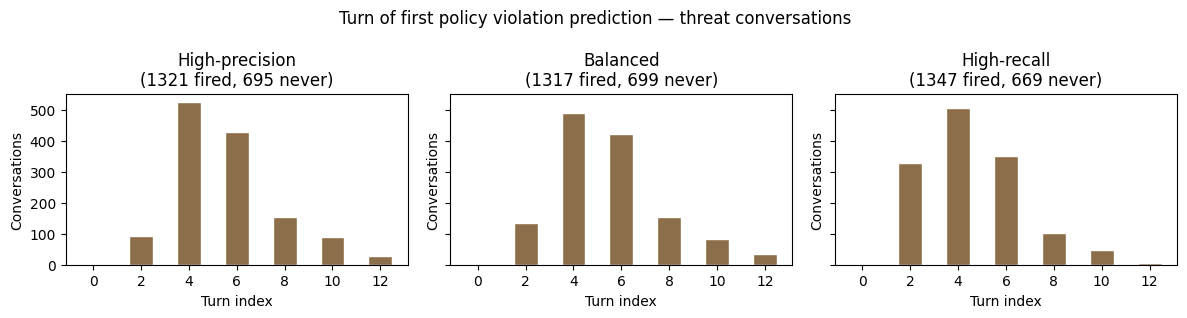

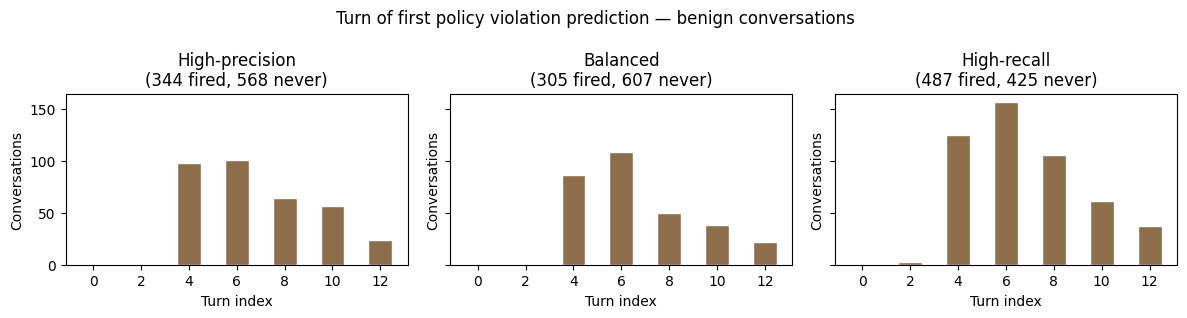

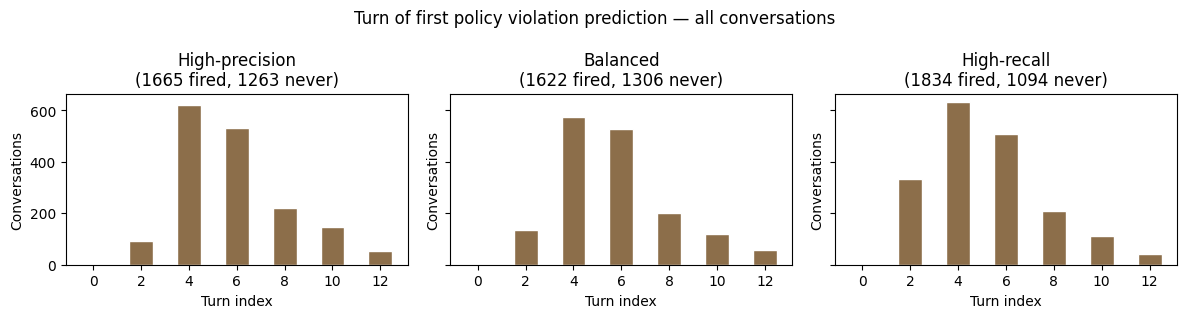

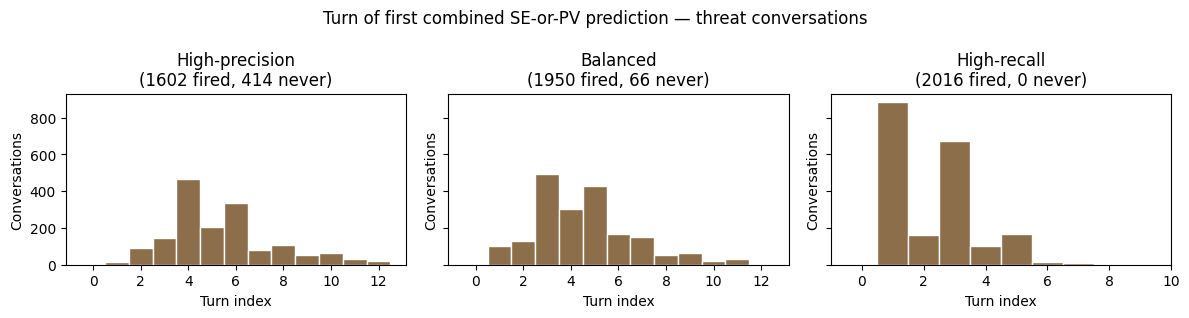

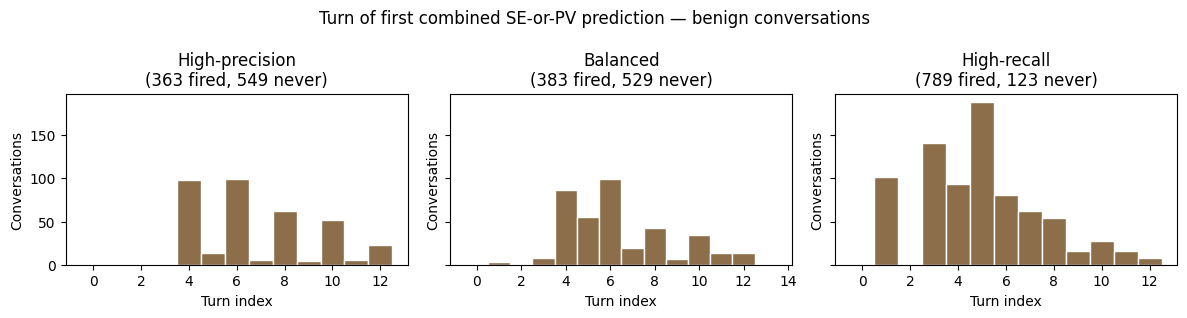

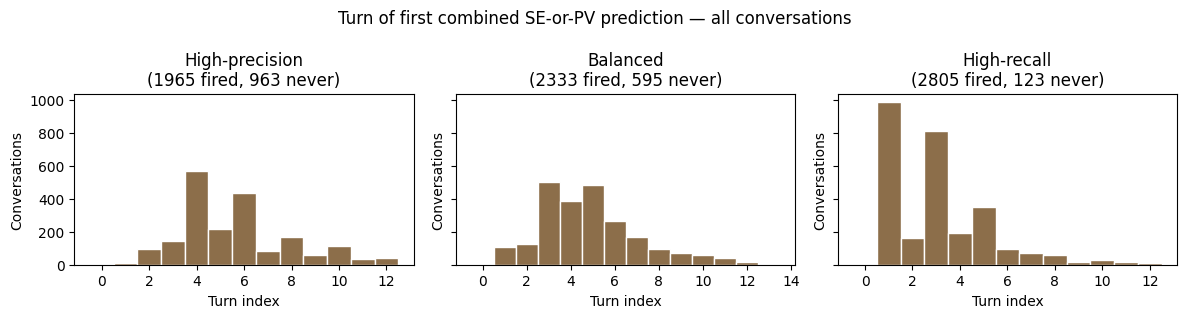

In [10]:
# Turn of first prediction by stance (one panel per stance), for SE / PV / combined
for objective in ('social_engineering', 'policy_violation', 'combined'):
    for filt in ('threat', 'benign', None):
        figures.hist_first_prediction_turn_by_stance(
            combined_conv, objective=objective, conversation_filter=filt)

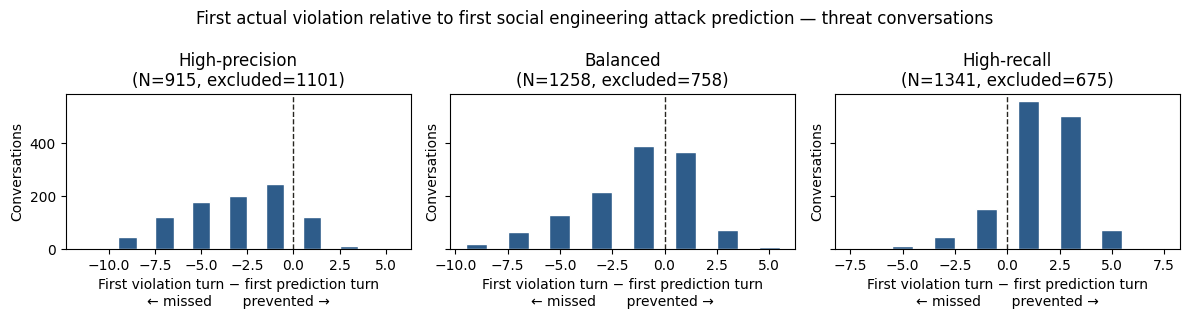

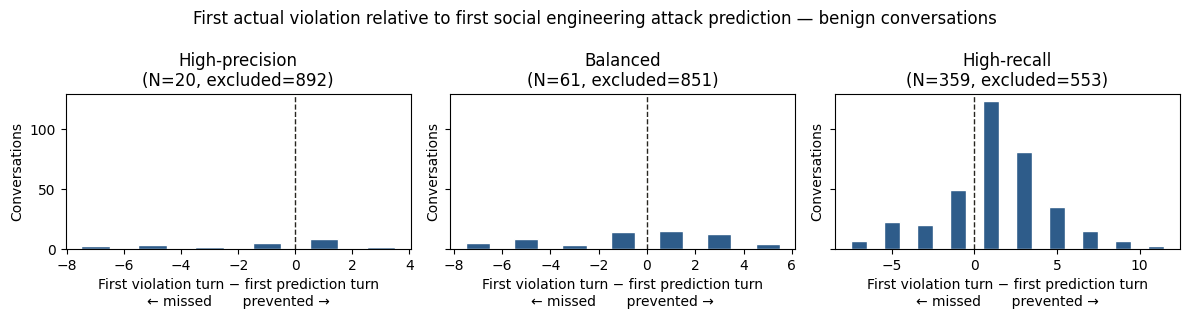

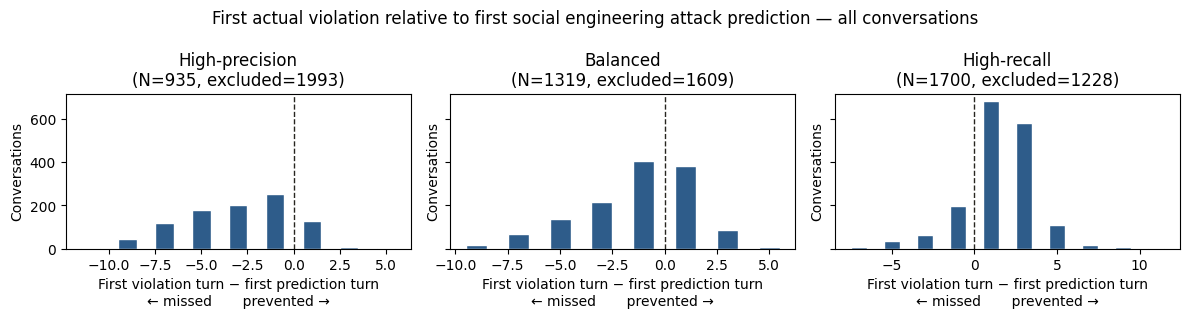

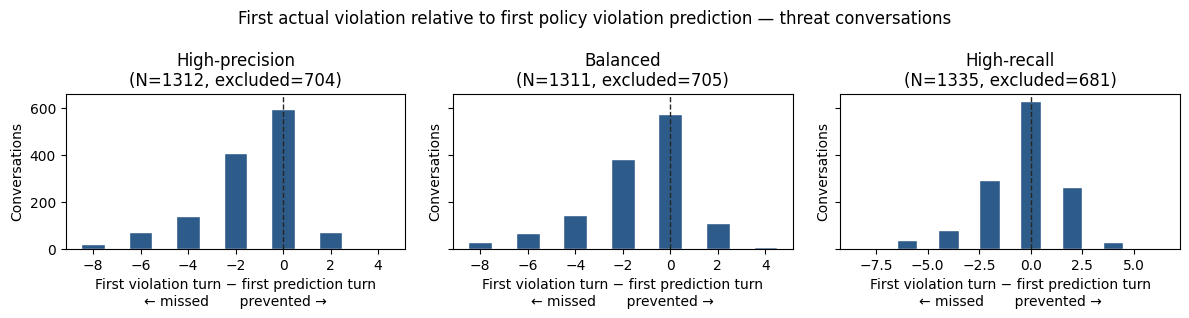

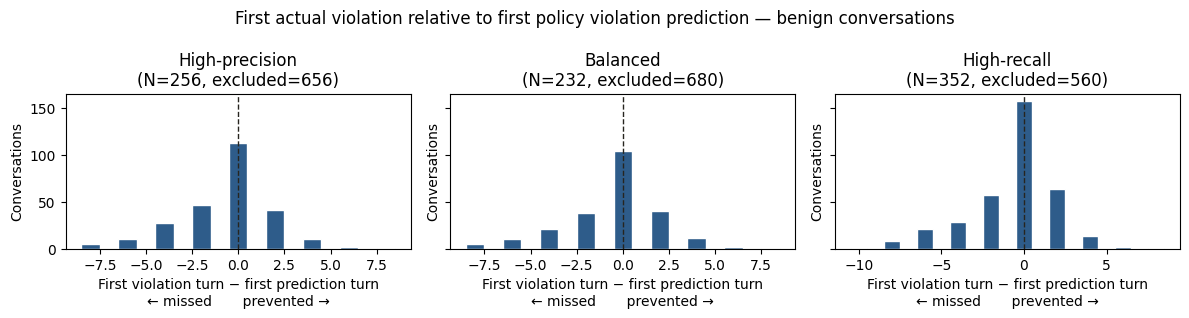

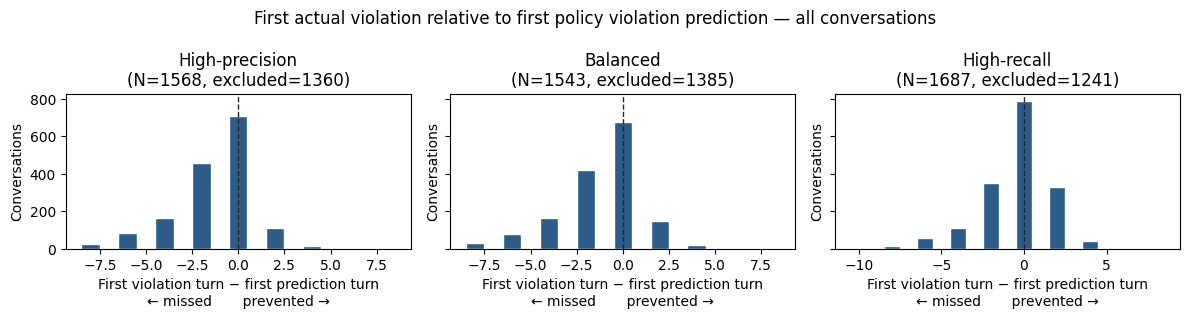

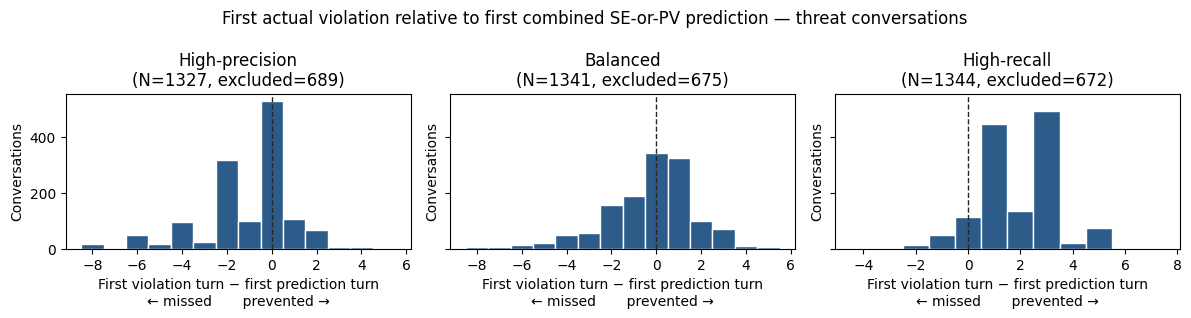

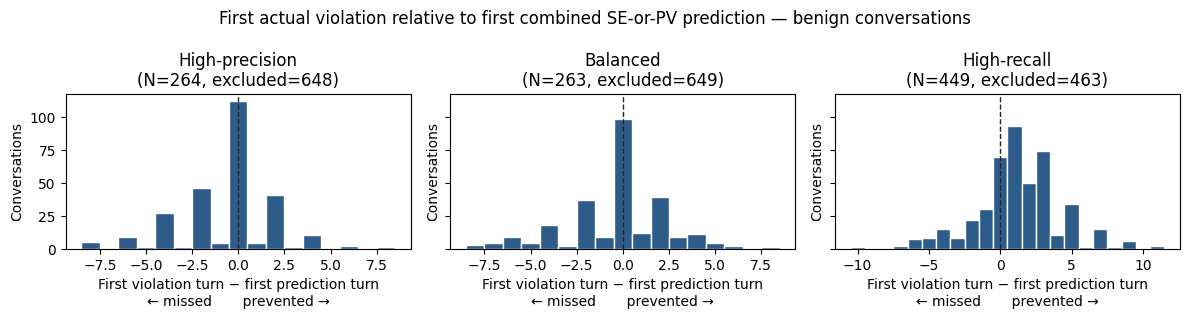

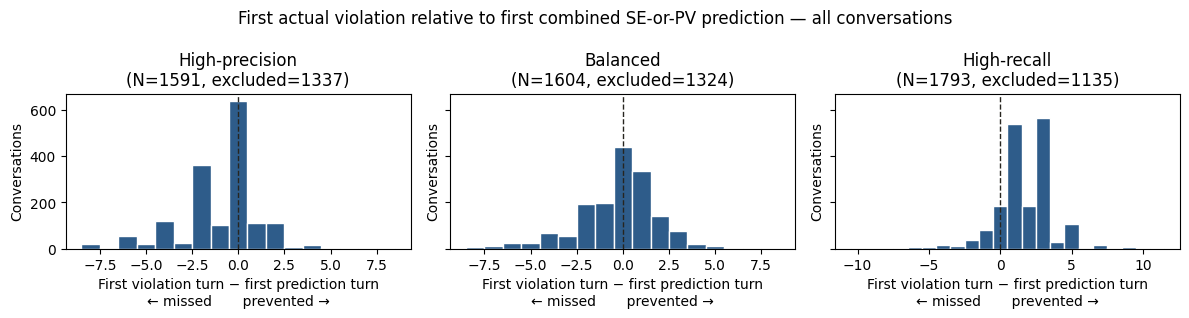

In [11]:
# First actual violation turn minus first prediction turn, by stance.
# Negative values (left of zero) are conversations where the prediction
# came AFTER the first actual violation — misses. Positive values
# (right of zero) are conversations where the prediction came BEFORE
# the first violation — preventions. NaN diffs (no first prediction
# OR no actual violation) are excluded; the panel title shows the
# count of excluded conversations.
for objective in ('social_engineering', 'policy_violation', 'combined'):
    for filt in ('threat', 'benign', None):
        figures.hist_violation_minus_pred_diff(
            combined_conv, objective=objective, conversation_filter=filt)

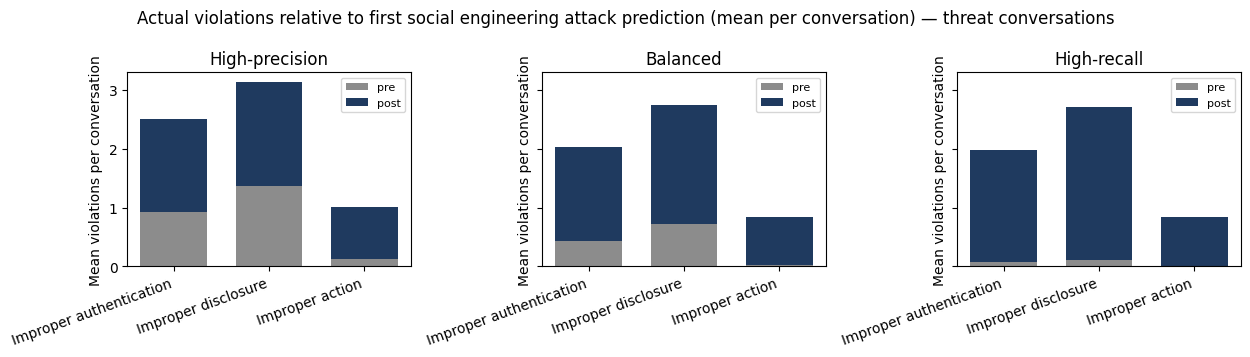

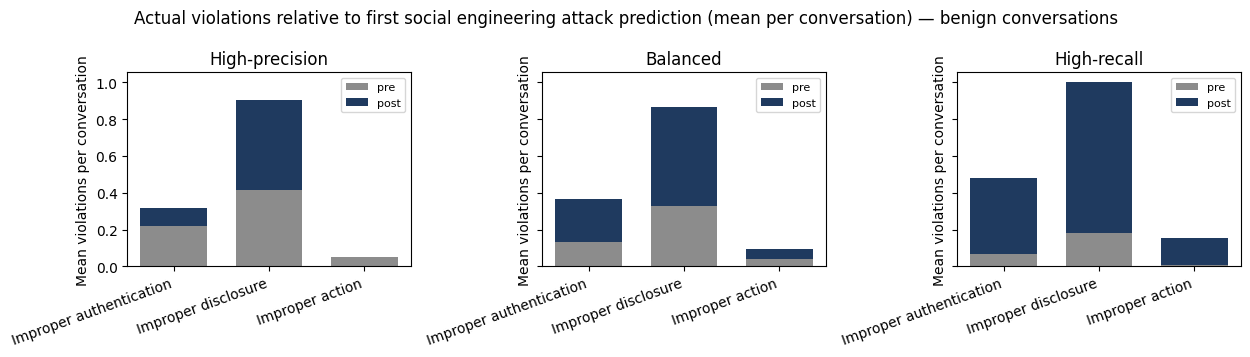

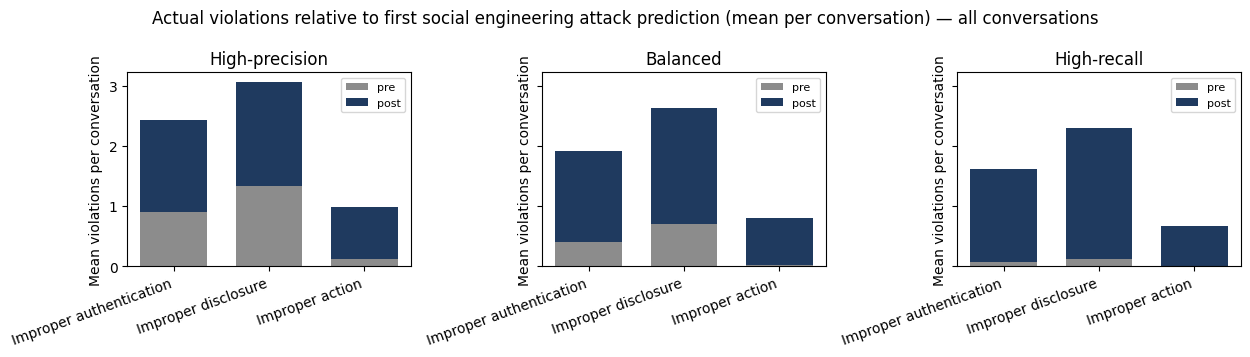

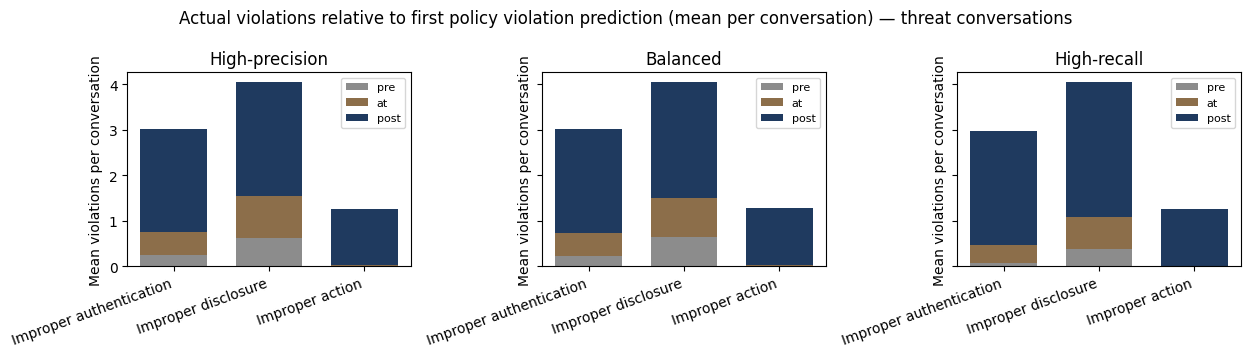

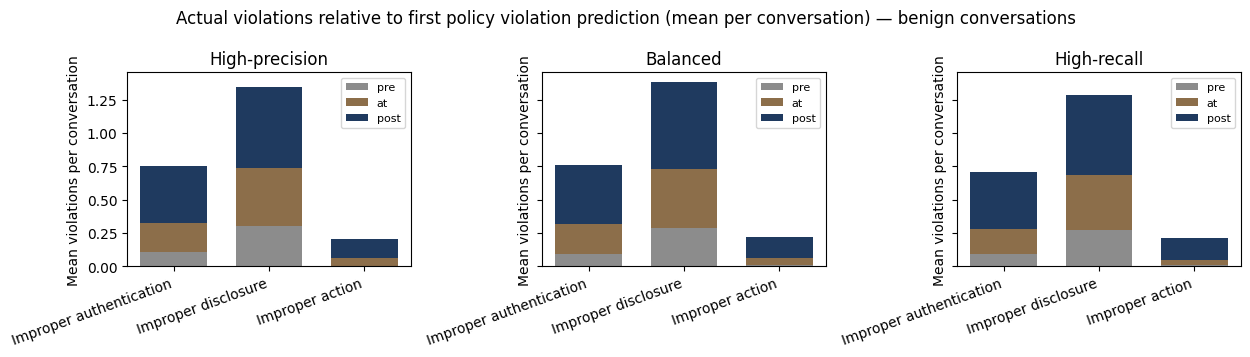

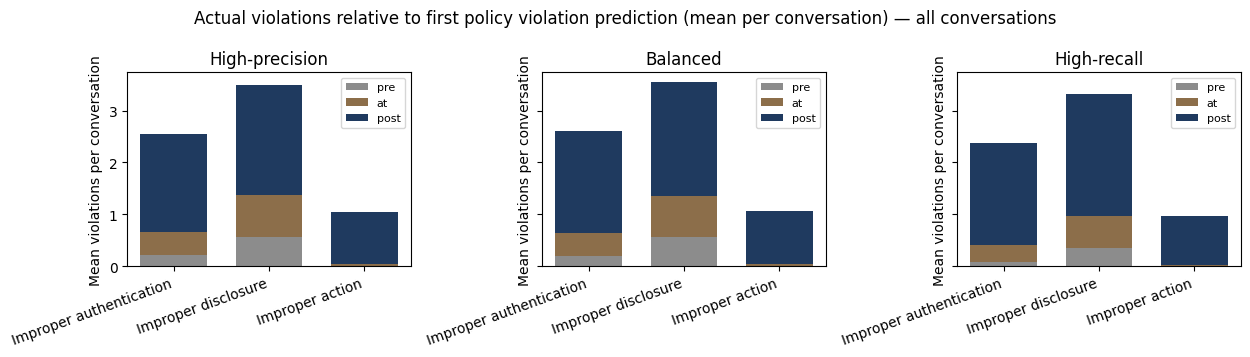

In [12]:
# Number of actual policy violations pre/at/post first prediction, by violation type.
# For SE the 'at' bar is suppressed (SE fires on caller turns; first violation is
# always a rep-response turn, so they cannot coincide). For PV all three bars show.
for objective in ('social_engineering', 'policy_violation'):
    for filt in ('threat', 'benign', None):
        figures.hist_violations_pre_at_post(
            combined_conv, objective=objective, conversation_filter=filt)

### 4.4 Heatmap: prompted Cialdini emphasis × Cialdini signals actually present

Rows = the principle the generator was *prompted* to emphasize. Columns = each Cialdini principle. Cell values = mean count of that principle's signals per conversation (for the prompted-emphasis row).

Both axes use the canonical Cialdini ordering. Restricted to threat conversations: the Cialdini emphasis prompt only meaningfully shapes threat generation. The diagonal should dominate if the generator obeyed the prompted emphasis; off-diagonal mass shows leakage of other principles.

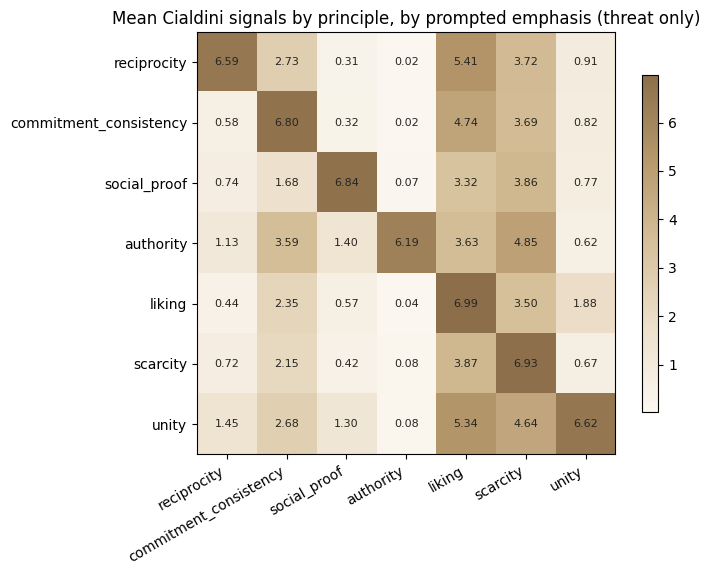

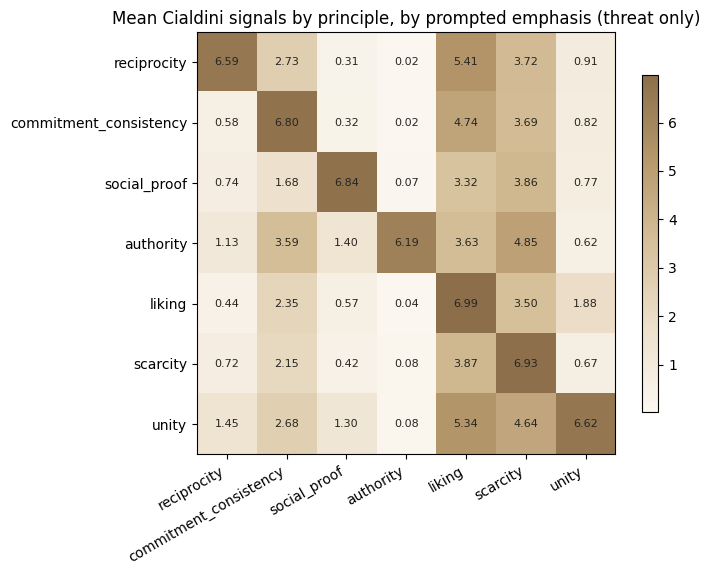

In [13]:
threat_only = combined_conv[combined_conv['conversation_type'] == 'threat']
emphasis_col = ('short_cialdini_emphasis'
                if 'short_cialdini_emphasis' in threat_only.columns
                else 'cialdini_emphasis')
if emphasis_col == 'short_cialdini_emphasis':
    emphasis_label = threat_only[emphasis_col]
else:
    emphasis_label = threat_only[emphasis_col].apply(S.cialdini_principle_label)

actual = threat_only.groupby(emphasis_label)[
    [f'total_cialdini_{p}' for p in S.CIALDINI_PRINCIPLES]
].mean()
actual.columns = [c.replace('total_cialdini_', '') for c in actual.columns]
# Canonical ordering on both axes
observed_rows = list(actual.index)
in_canonical = [p for p in S.CIALDINI_PRINCIPLES if p in observed_rows]
extras = sorted([r for r in observed_rows if r not in in_canonical], key=str)
actual = actual.reindex(in_canonical + extras)
actual.index.name = 'prompted_emphasis'

figures.heatmap_from_dataframe(
    actual,
    title='Mean Cialdini signals by principle, by prompted emphasis (threat only)',
    name='heatmap_prompted_x_actual_cialdini',
    fmt='{:.2f}',
)

### 4.5 Sankey: conversation flow through key states

Type → had-violation → SE-predicted → PV-predicted, one Sankey per stance.

In [14]:
for stance in S.STANCES:
    figures.sankey_threat_to_outcomes(
        combined_conv, se_stance=stance, pv_stance=stance,
        name=f'sankey_threat_to_outcomes__{stance}',
    )

### 4.6 Aggregation-rule sensitivity

How does conversation-level recall on threat conversations change when we vary the rule for declaring "the conversation is flagged"?

In [15]:
agg_rules = pd.concat([
    query.conversation_recall_under_aggregation_rules(ctx, objective='social_engineering'),
    query.conversation_recall_under_aggregation_rules(ctx, objective='policy_violation'),
], ignore_index=True)
figures.save_table('conversation_recall_aggregation_rules', agg_rules, index=False)
agg_rules

,objective,stance,rule,n_threat_conversations,n_flagged,recall
0,social_engineering,high_precision,any,2016,1187,0.588790
1,social_engineering,high_precision,two_or_more,2016,641,0.317956
2,social_engineering,high_precision,majority,2016,149,0.073909
3,social_engineering,balanced,any,2016,1867,0.926091
4,social_engineering,balanced,two_or_more,2016,1518,0.752976
5,social_engineering,balanced,majority,2016,641,0.317956
6,social_engineering,high_recall,any,2016,2013,0.998512
7,social_engineering,high_recall,two_or_more,2016,2007,0.995536
8,social_engineering,high_recall,majority,2016,1846,0.915675
9,policy_violation,high_precision,any,2016,1321,0.655258


## 5. Investigation of research questions: ROC / AUC analysis

Four scenarios. Three sensitivity stances act as three operating points; together with (0,0) and (1,1) they yield a 5-point empirical ROC. AUC computed by trapezoidal rule and reported to three decimal places.

**The PV scenarios use violation status as the positive-class label, NOT the threat/benign conversation label.** A benign conversation with an actual violation counts as positive; a threat conversation with no violation counts as negative.

For each scenario:
1. Overall ROC and AUC.
2. ROC by Cialdini emphasis (one curve per principle, canonical order).
3. ROC by amount of benign context (one curve per level, canonical order).
4. Heatmap: amount of benign context × Cialdini emphasis, AUC values.


=== Social engineering attack detection ===
  overall AUC = 0.923  (positives=2016, negatives=912)

=== Social engineering attack prevention ===
  overall AUC = 0.757  (positives=2016, negatives=912)

=== Policy violation detection ===
  overall AUC = 0.909  (positives=1834, negatives=1094)

=== Policy violation on-time prediction ===
  overall AUC = 0.657  (positives=1834, negatives=1094)


,scenario,breakdown,slice_label,auc,n_positive,n_negative
0,se_detection,overall,overall,0.923,2016,912
1,se_detection,cialdini_emphasis,reciprocity,0.923,288,131
2,se_detection,cialdini_emphasis,commitment_consistency,0.888,288,131
3,se_detection,cialdini_emphasis,social_proof,0.940,288,130
4,se_detection,cialdini_emphasis,authority,0.939,288,130
5,se_detection,cialdini_emphasis,liking,0.887,288,130
6,se_detection,cialdini_emphasis,scarcity,0.955,288,130
7,se_detection,cialdini_emphasis,unity,0.940,288,130
8,se_detection,benign_context,minimal,0.928,672,297
9,se_detection,benign_context,moderate,0.919,672,307


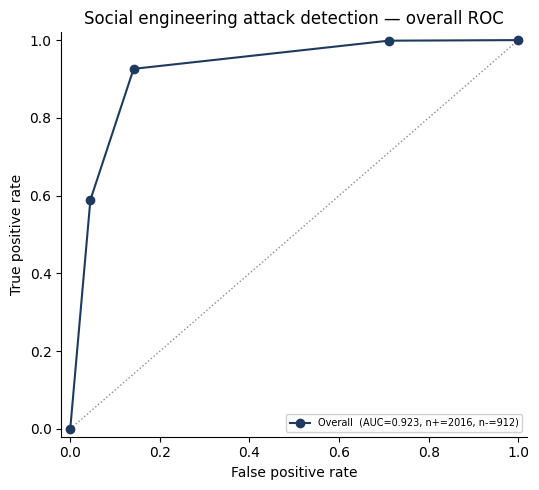

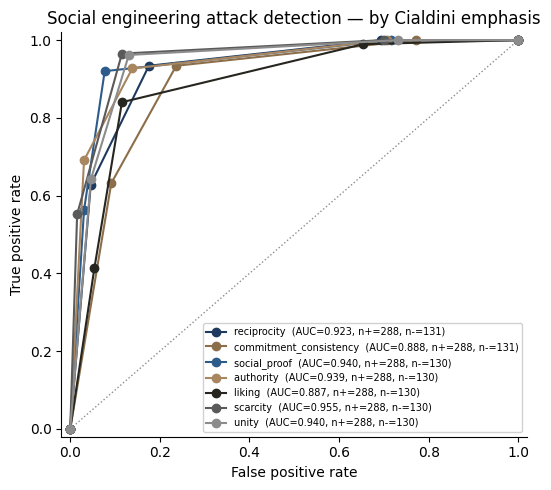

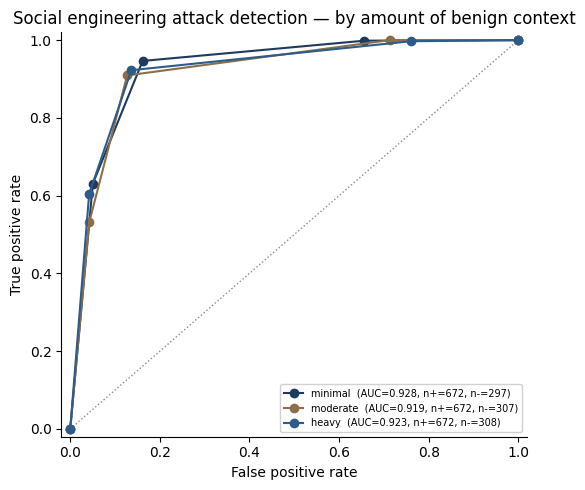

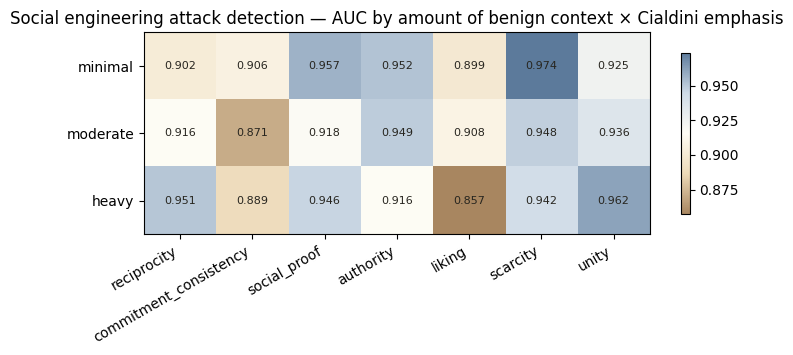

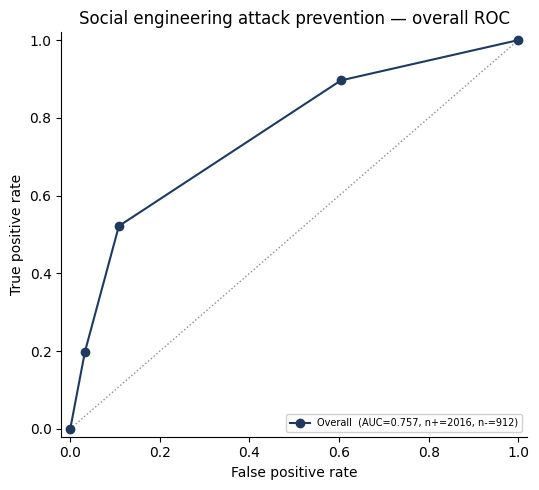

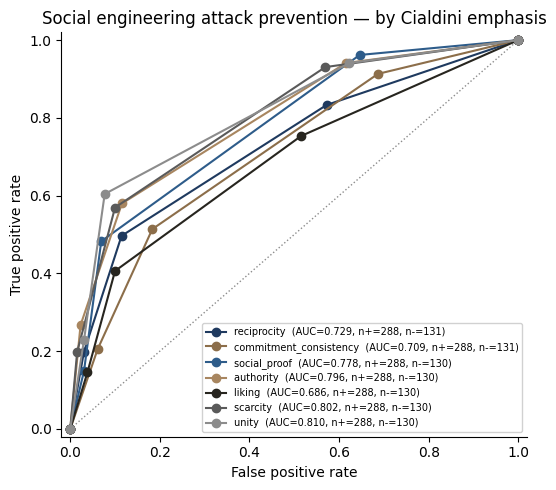

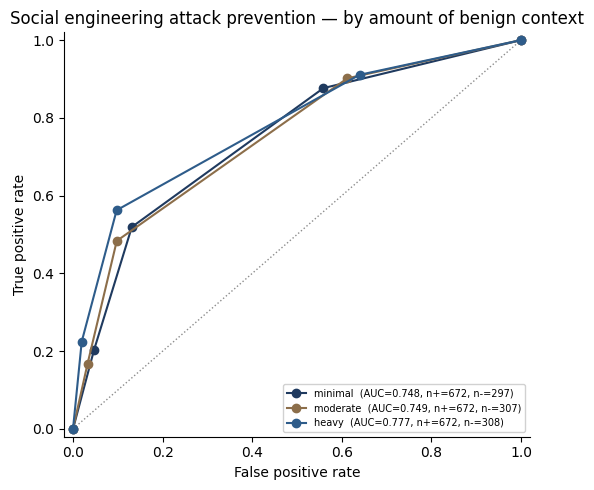

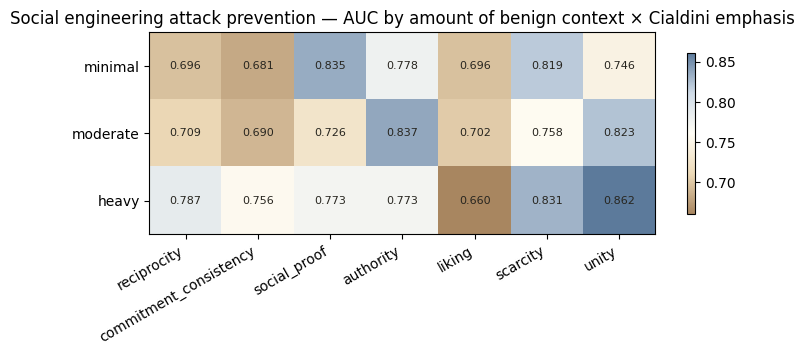

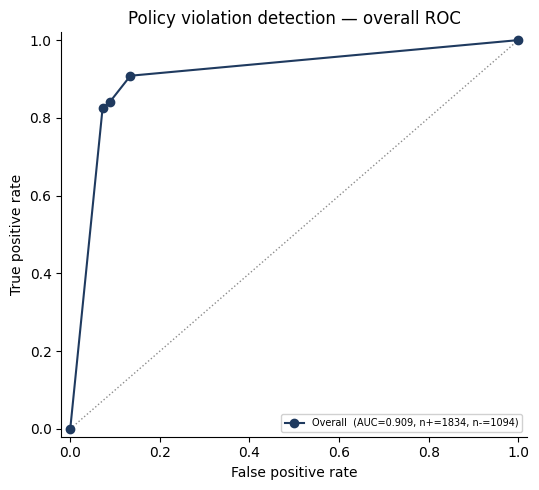

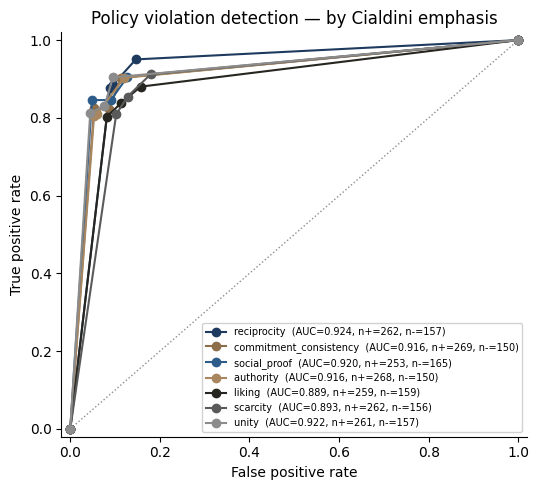

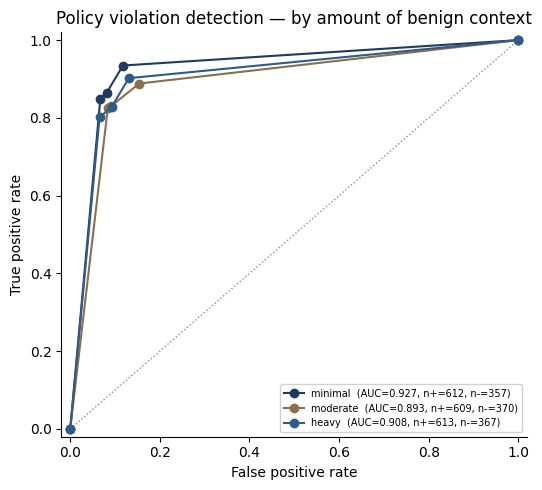

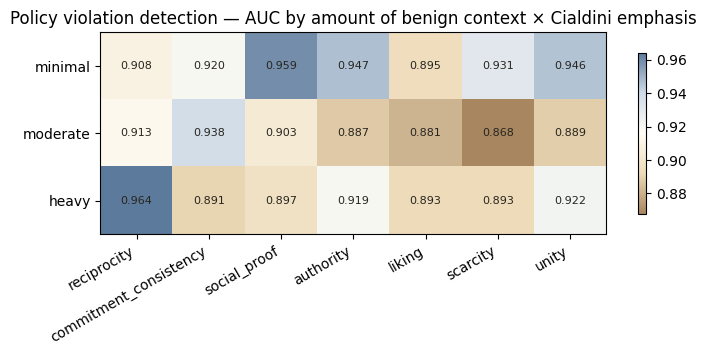

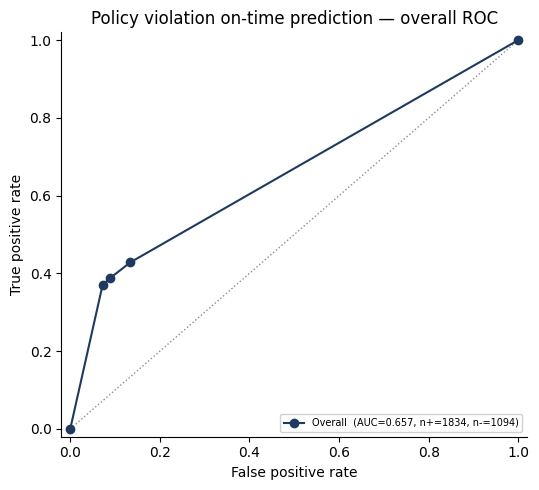

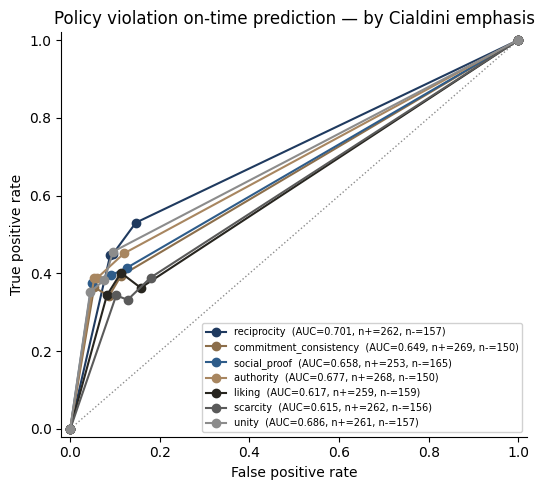

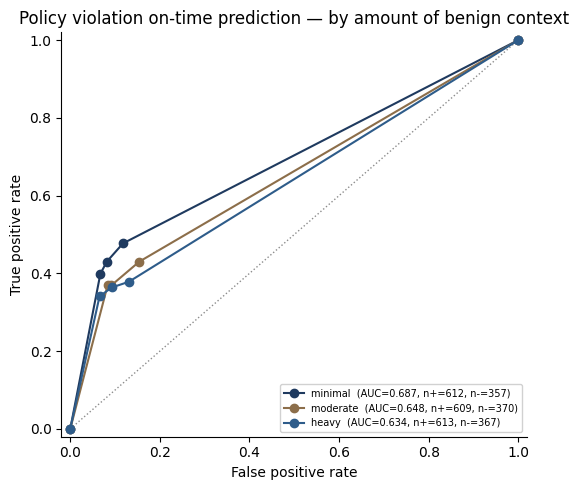

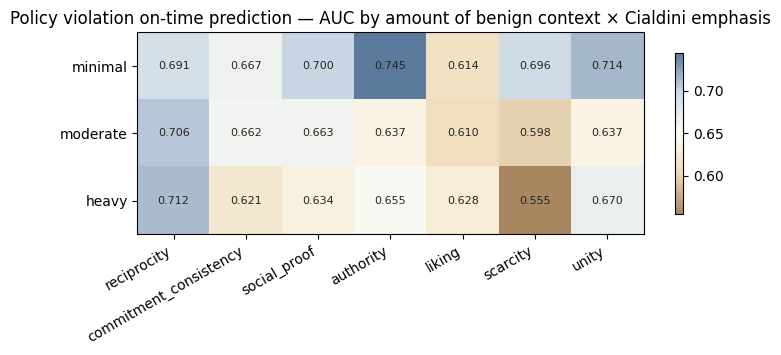

In [16]:
auc_summary_rows = []
for scen in roc.SCENARIOS:
    pretty = figures._pretty_scenario(scen)
    print(f'\n=== {pretty} ===')

    # 1. Overall
    r_overall = roc.compute_roc(
        combined_conv, combined_turns, scen, slice_label='Overall')
    figures.plot_roc_curves(
        [r_overall], title=f'{pretty} — overall ROC',
        name=f'roc__{scen}__overall')
    print(f'  overall AUC = {r_overall.auc:.3f}  '
          f'(positives={r_overall.n_pos}, negatives={r_overall.n_neg})')
    auc_summary_rows.append({
        'scenario': scen, 'breakdown': 'overall',
        'slice_label': 'overall', 'auc': round(r_overall.auc, 3),
        'n_positive': r_overall.n_pos, 'n_negative': r_overall.n_neg,
    })

    # 2. By Cialdini emphasis (uses short_cialdini_emphasis if present;
    #    falls back to raw cialdini_emphasis with on-the-fly labeling)
    cialdini_col = ('short_cialdini_emphasis'
                    if 'short_cialdini_emphasis' in combined_conv.columns
                    else 'cialdini_emphasis')
    r_by_cialdini = roc.compute_roc_by_slice(
        combined_conv, combined_turns, scen, cialdini_col)
    figures.plot_roc_curves(
        r_by_cialdini, title=f'{pretty} — by Cialdini emphasis',
        name=f'roc__{scen}__by_cialdini')
    for r in r_by_cialdini:
        auc_summary_rows.append({
            'scenario': scen, 'breakdown': 'cialdini_emphasis',
            'slice_label': r.slice_label, 'auc': round(r.auc, 3),
            'n_positive': r.n_pos, 'n_negative': r.n_neg,
        })

    # 3. By amount of benign context
    context_col = ('short_benign_context'
                   if 'short_benign_context' in combined_conv.columns
                   else 'benign_context')
    r_by_context = roc.compute_roc_by_slice(
        combined_conv, combined_turns, scen, context_col)
    figures.plot_roc_curves(
        r_by_context, title=f'{pretty} — by amount of benign context',
        name=f'roc__{scen}__by_benign_context')
    for r in r_by_context:
        auc_summary_rows.append({
            'scenario': scen, 'breakdown': 'benign_context',
            'slice_label': r.slice_label, 'auc': round(r.auc, 3),
            'n_positive': r.n_pos, 'n_negative': r.n_neg,
        })

    # 4. Heatmap: AUC by (benign_context, cialdini_emphasis)
    heat = roc.auc_heatmap_table(
        combined_conv, combined_turns, scen,
        row_column=context_col,
        col_column=cialdini_col,
    )
    figures.heatmap_from_dataframe(
        heat,
        title=f'{pretty} — AUC by amount of benign context × Cialdini emphasis',
        name=f'heatmap_auc__{scen}',
        fmt='{:.3f}',
        cmap=figures.UNCC_DIVERGING_CMAP,
    )

auc_summary_df = pd.DataFrame(auc_summary_rows)
figures.save_table('auc_summary_all_scenarios', auc_summary_df, index=False)
auc_summary_df

### 5b. Operating-points detail

Per-stance TP/FP/TPR/FPR for each scenario's overall ROC.

In [17]:
all_overall_results = [
    roc.compute_roc(combined_conv, combined_turns, s, slice_label='Overall')
    for s in roc.SCENARIOS
]
op_pts = roc.operating_points_to_dataframe(all_overall_results)
op_pts['auc'] = op_pts['auc'].round(3)
figures.save_table('roc_operating_points_overall', op_pts, index=False)
op_pts

,scenario,slice_label,stance,n_positive_conversations,n_negative_conversations,tp,fp,tpr,fpr,auc
0,se_detection,Overall,high_precision,2016,912,1187,41,0.588790,0.044956,0.923
1,se_detection,Overall,balanced,2016,912,1867,129,0.926091,0.141447,0.923
2,se_detection,Overall,high_recall,2016,912,2013,648,0.998512,0.710526,0.923
3,se_prevention,Overall,high_precision,2016,912,401,30,0.198909,0.032895,0.757
4,se_prevention,Overall,balanced,2016,912,1052,99,0.521825,0.108553,0.757
5,se_prevention,Overall,high_recall,2016,912,1807,551,0.896329,0.604167,0.757
6,pv_detection,Overall,high_precision,1834,1094,1543,97,0.841330,0.088665,0.909
7,pv_detection,Overall,balanced,1834,1094,1513,79,0.824973,0.072212,0.909
8,pv_detection,Overall,high_recall,1834,1094,1666,147,0.908397,0.134369,0.909
9,pv_on_time,Overall,high_precision,1834,1094,711,97,0.387677,0.088665,0.657
